# VIP Churn — v3 (All Bugs Fixed + New Features)

**What changed from v2:**

| # | Bug / Gap | Fix |
|---|-----------|-----|
| 1 | `scale_pos_weight=0.34` was REDUCING churner penalty (wrong direction) | Replaced with `compute_sample_weight` — correct class 0 boosting |
| 2 | LR fails on right-skewed monetary features | `ColumnTransformer`: log-transform monetary cols, scale rest |
| 3 | `Pre_Monetary` conflates tenure length with loyalty rate | Added `Pre_Monthly_Rate` = Pre_Monetary ÷ pre_months |
| 4 | No signal for "holiday spike vs normal" | Added `Holiday_Spend_Share` and `Frequency_Ratio` |
| 5 | No single loyalty composite | Added `Pre_Loyalty_Score` = log(monetary × frequency / recency+1) |
| 6 | XGB never searched enough space | `n_iter` raised to 40, added `reg_alpha`, `reg_lambda` |
| 7 | Both models used same LR pipeline for comparison | XGB now has its own separate pipeline — no shared scaler |

**Run order: Cell 1 → 14, top to bottom, never skip.**

In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dask
import dask.dataframe as dd
import joblib

from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    make_scorer, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Custom scorer: optimise for catching churners (class 0)
churn_f1_scorer = make_scorer(f1_score, pos_label=0)

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD, MERGE & CLEAN  (unchanged — already correct)
# ============================================================
print('STEP 1: Loading parquet files...')
df_main = dd.read_parquet('transactions_parquet/')
df_time  = dd.read_parquet('time_parquet/')

print('STEP 2: Merging on SHOP_WEEK...')
df_time = df_time.rename(columns={'shop_week': 'SHOP_WEEK'})
df = dd.merge(df_main, df_time, on='SHOP_WEEK', how='left')

print('STEP 3: Basic cleaning...')
critical_cols = ['CUST_CODE', 'SPEND', 'QUANTITY', 'SHOP_DATE']
df_clean = df.dropna(subset=critical_cols)
df_clean = df_clean[(df_clean['QUANTITY'] > 0) & (df_clean['SPEND'] > 0)]

print('STEP 4: Parsing dates...')
df_clean['Transaction_Date'] = dd.to_datetime(
    df_clean['SHOP_DATE'], format='%Y%m%d', errors='coerce'
)
df_clean = df_clean.dropna(subset=['Transaction_Date'])

print('STEP 5: Outlier cap at 99th percentile...')
spend_99, qty_99 = dask.compute(
    df_clean['SPEND'].quantile(0.99),
    df_clean['QUANTITY'].quantile(0.99)
)
print(f'   -> Spend cap: £{spend_99:.2f}  |  Qty cap: {qty_99:.0f} units')
df_final = df_clean[
    (df_clean['SPEND'] <= spend_99) &
    (df_clean['QUANTITY'] <= qty_99)
]

core_columns = ['CUST_CODE', 'Transaction_Date', 'SPEND', 'QUANTITY', 'PROD_CODE', 'BASKET_ID']
df_model = df_final[core_columns].dropna()
final_rows = df_model.map_partitions(len).compute().sum()

print(f'\nCLEANING COMPLETE — {final_rows:,} valid transactions')
display(df_model.head(3))

STEP 1: Loading parquet files...
STEP 2: Merging on SHOP_WEEK...
STEP 3: Basic cleaning...
STEP 4: Parsing dates...
STEP 5: Outlier cap at 99th percentile...
   -> Spend cap: £16.29  |  Qty cap: 10 units

CLEANING COMPLETE — 245,976,814 valid transactions


,CUST_CODE,Transaction_Date,SPEND,QUANTITY,PROD_CODE,BASKET_ID
0,CUST0000167145,2006-04-10,1.01,1,PRD0900005,994100100253028
1,CUST0000246027,2006-04-16,3.03,3,PRD0900005,994100100299966
2,CUST0000140993,2006-04-13,0.22,1,PRD0900006,994100100237197


In [3]:
# ============================================================
# CELL 3 — SAFE TIME SLICING  (unchanged — already correct)
# ============================================================
max_date = df_model['Transaction_Date'].max().compute()

if max_date >= pd.to_datetime(f'{max_date.year}-06-30'):
    target_year = max_date.year - 1
else:
    target_year = max_date.year - 2

holiday_start = pd.to_datetime(f'{target_year}-11-01')
holiday_end   = pd.to_datetime(f'{target_year}-12-31')
post_start    = pd.to_datetime(f'{target_year + 1}-01-01')
post_end      = pd.to_datetime(f'{target_year + 1}-06-30')

# Pre-holiday months count — needed for Pre_Monthly_Rate feature
# Data starts 2006-04, holiday starts 2007-11-01 = ~19 months
data_start    = df_model['Transaction_Date'].min().compute()
pre_months    = max(1, (holiday_start - data_start).days / 30.44)

print(f'Dataset range      : {data_start.date()} → {max_date.date()}')
print(f'Pre-holiday window : {data_start.date()} → {holiday_start.date()} ({pre_months:.1f} months)')
print(f'Holiday peak       : {holiday_start.date()} → {holiday_end.date()}')
print(f'Post-holiday track : {post_start.date()} → {post_end.date()}')

holiday_df      = df_model[
    (df_model['Transaction_Date'] >= holiday_start) &
    (df_model['Transaction_Date'] <= holiday_end)
]
post_holiday_df = df_model[
    (df_model['Transaction_Date'] >= post_start) &
    (df_model['Transaction_Date'] <= post_end)
]
pre_holiday_df  = df_model[df_model['Transaction_Date'] < holiday_start]

print('\nTime windows sliced. Ready for feature engineering.')

Dataset range      : 2006-04-10 → 2008-07-06
Pre-holiday window : 2006-04-10 → 2007-11-01 (18.7 months)
Holiday peak       : 2007-11-01 → 2007-12-31
Post-holiday track : 2008-01-01 → 2008-06-30

Time windows sliced. Ready for feature engineering.


In [4]:
# ============================================================
# CELL 4 — FEATURE ENGINEERING  (expanded — all in one Dask batch)
#
# NEW FEATURES vs v2:
#   Pre_Monthly_Rate     — Pre_Monetary ÷ pre_months (normalises for tenure)
#   Holiday_Spend_Share  — Holiday spend as % of total annual spend
#   Frequency_Ratio      — Holiday visits per month vs Pre visits per month
#   Pre_Loyalty_Score    — Composite: log(monetary × frequency / recency+1)
# ============================================================
print('Computing HOLIDAY features (lazy)...')
h_group     = holiday_df.groupby('CUST_CODE')
h_last_date = h_group['Transaction_Date'].max()
h_freq      = h_group['BASKET_ID'].nunique()
h_monetary  = h_group['SPEND'].sum()
h_uniq_prod = h_group['PROD_CODE'].nunique()
h_qty       = h_group['QUANTITY'].sum()

nov_df      = holiday_df[holiday_df['Transaction_Date'].dt.month == 11]
dec_df      = holiday_df[holiday_df['Transaction_Date'].dt.month == 12]
h_nov_spend = nov_df.groupby('CUST_CODE')['SPEND'].sum()
h_dec_spend = dec_df.groupby('CUST_CODE')['SPEND'].sum()

print('Computing PRE-HOLIDAY features (lazy)...')
pre_group     = pre_holiday_df.groupby('CUST_CODE')
pre_freq      = pre_group['BASKET_ID'].nunique()
pre_monetary  = pre_group['SPEND'].sum()
pre_last_date = pre_group['Transaction_Date'].max()

post_unique   = post_holiday_df['CUST_CODE'].unique()

print('\nFiring single parallel Dask compute...')
(
    h_last_date, h_freq, h_monetary, h_uniq_prod, h_qty,
    h_nov_spend, h_dec_spend,
    pre_freq, pre_monetary, pre_last_date,
    retained_customers
) = dask.compute(
    h_last_date, h_freq, h_monetary, h_uniq_prod, h_qty,
    h_nov_spend, h_dec_spend,
    pre_freq, pre_monetary, pre_last_date,
    post_unique
)

# --- Build holiday feature table ---
hf = pd.concat([
    h_last_date.rename('Last_Purchase_Date'),
    h_freq.rename('Holiday_Frequency'),
    h_monetary.rename('Holiday_Monetary'),
    h_uniq_prod.rename('Holiday_UniqueProducts'),
    h_qty.rename('Holiday_TotalItems'),
    h_nov_spend.rename('Nov_Spend'),
    h_dec_spend.rename('Dec_Spend'),
], axis=1).reset_index()

hf['Last_Purchase_Date'] = pd.to_datetime(hf['Last_Purchase_Date'], errors='coerce')
hf = hf.dropna(subset=['Last_Purchase_Date'])

hf['Holiday_Recency']          = (holiday_end - hf['Last_Purchase_Date']).dt.days
hf['Holiday_ProductDiversity'] = hf['Holiday_UniqueProducts'] / hf['Holiday_TotalItems'].clip(lower=1)
hf['Avg_Basket_Size']          = hf['Holiday_Monetary'] / hf['Holiday_Frequency'].clip(lower=1)
hf['Holiday_Spend_Velocity']   = (
    np.log1p(hf['Dec_Spend']) - np.log1p(hf['Nov_Spend'].fillna(0))
)
hf.drop(columns=['Last_Purchase_Date', 'Holiday_UniqueProducts',
                  'Holiday_TotalItems', 'Nov_Spend', 'Dec_Spend'], inplace=True)

# --- Build pre-holiday feature table ---
pf = pd.concat([
    pre_freq.rename('Pre_Frequency'),
    pre_monetary.rename('Pre_Monetary'),
    pre_last_date.rename('Pre_LastDate'),
], axis=1).reset_index()

pf['Pre_LastDate'] = pd.to_datetime(pf['Pre_LastDate'], errors='coerce')
pf['Pre_Recency']  = (holiday_start - pf['Pre_LastDate']).dt.days.clip(lower=0)

# NEW: normalise Pre_Monetary by actual observation window length
pf['Pre_Monthly_Rate'] = pf['Pre_Monetary'] / pre_months   # £/month — removes tenure bias
pf.drop(columns=['Pre_LastDate'], inplace=True)

# --- Merge ---
ml_data = hf.merge(pf, on='CUST_CODE', how='left').fillna(0)
ml_data['Retained'] = ml_data['CUST_CODE'].isin(retained_customers).astype(int)
ml_data.set_index('CUST_CODE', inplace=True)

print('\n' + '='*55)
print('FEATURE ENGINEERING COMPLETE')
print('='*55)
print(f'Holiday shoppers : {len(ml_data):,}')
print(f'Features         : {list(c for c in ml_data.columns if c != "Retained")}')
print('='*55)
display(ml_data.head())

Computing HOLIDAY features (lazy)...
Computing PRE-HOLIDAY features (lazy)...

Firing single parallel Dask compute...

FEATURE ENGINEERING COMPLETE
Holiday shoppers : 309,415
Features         : ['Holiday_Frequency', 'Holiday_Monetary', 'Holiday_Recency', 'Holiday_ProductDiversity', 'Avg_Basket_Size', 'Holiday_Spend_Velocity', 'Pre_Frequency', 'Pre_Monetary', 'Pre_Recency', 'Pre_Monthly_Rate']


,Holiday_Frequency,Holiday_Monetary,Holiday_Recency,Holiday_ProductDiversity,Avg_Basket_Size,Holiday_Spend_Velocity,Pre_Frequency,Pre_Monetary,Pre_Recency,Pre_Monthly_Rate,Retained
CUST_CODE,,,,,,,,,,,
CUST0000000327,29,196.01,0,0.408163,6.758966,0.398610,252.0,1148.77,1.0,61.348349,1
CUST0000001173,22,129.84,3,0.543046,5.901818,-0.282198,312.0,2221.38,1.0,118.629486,1
CUST0000001247,13,35.63,2,0.642857,2.740769,-0.114395,150.0,1070.39,10.0,57.162582,1
CUST0000001981,6,20.52,33,0.473684,3.420000,0.000000,54.0,110.70,88.0,5.911768,1
CUST0000002098,3,96.54,12,0.596774,32.180000,0.291057,18.0,835.41,24.0,44.613825,1


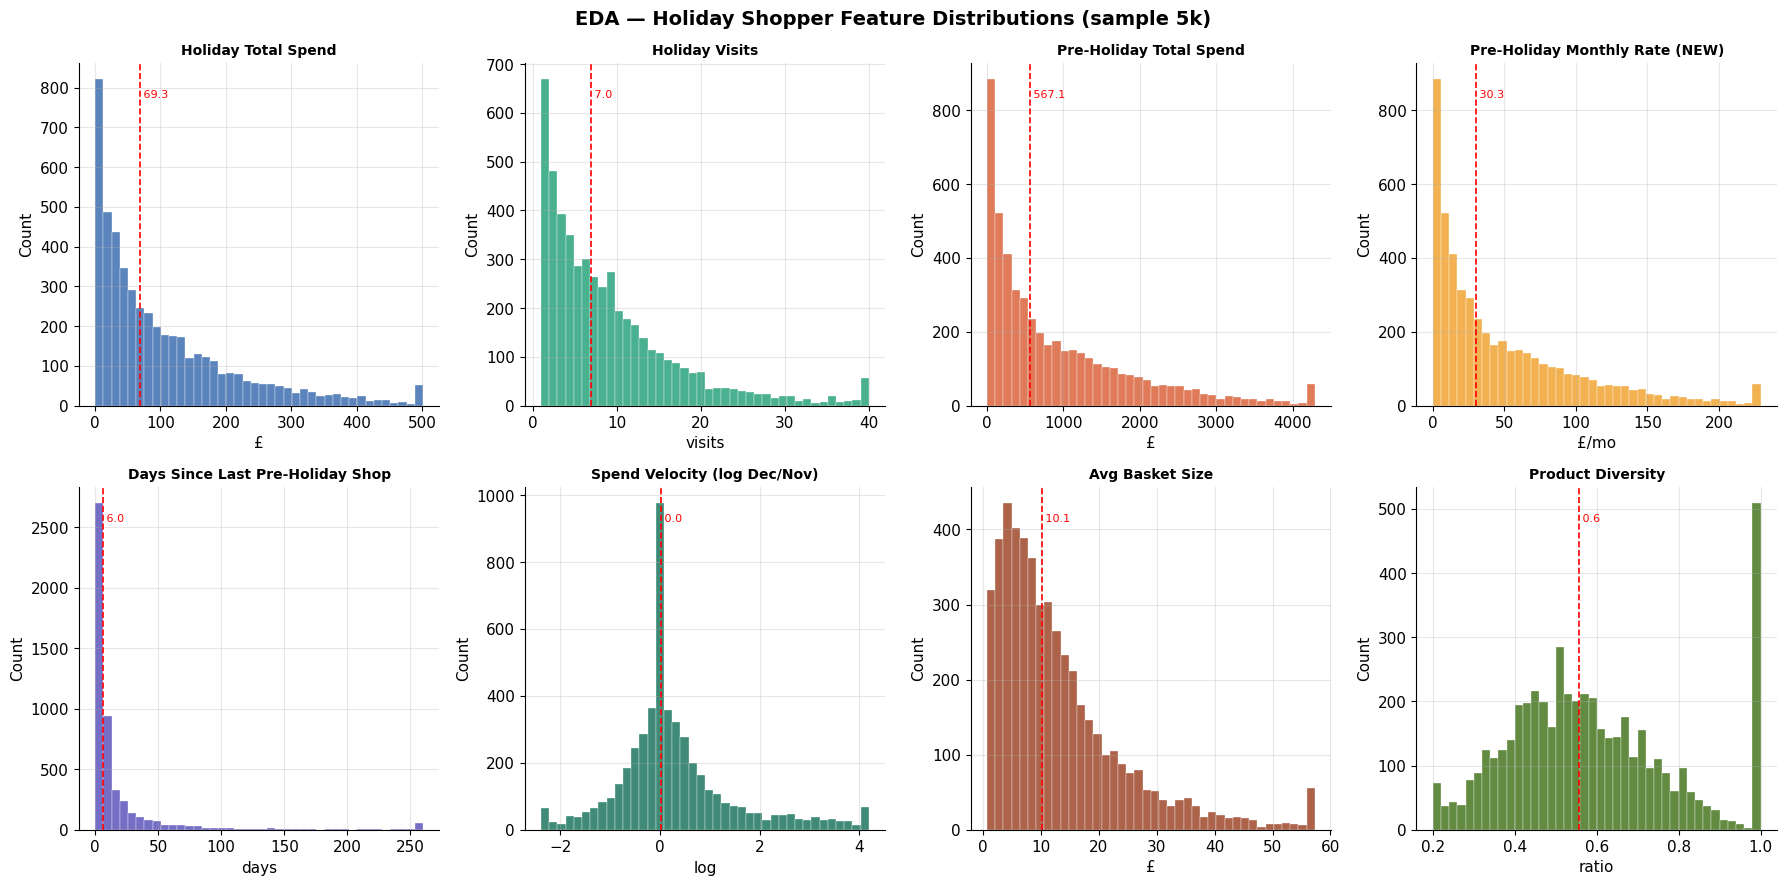

Saved: viz_01_eda.png

KEY OBSERVATION: Holiday_Monetary and Pre_Monetary are heavily right-skewed.
This hurts Logistic Regression. Fix applied in Cell 11 (log-transform pipeline).


In [5]:
# ============================================================
# CELL 5 — VISUALISATION 1: EDA distributions
# ============================================================
sample = ml_data.sample(n=min(5000, len(ml_data)), random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('EDA — Holiday Shopper Feature Distributions (sample 5k)', fontsize=14, fontweight='bold')

plot_cols = [
    ('Holiday_Monetary',      '£',    'Holiday Total Spend'),
    ('Holiday_Frequency',     'visits','Holiday Visits'),
    ('Pre_Monetary',          '£',    'Pre-Holiday Total Spend'),
    ('Pre_Monthly_Rate',      '£/mo', 'Pre-Holiday Monthly Rate (NEW)'),
    ('Pre_Recency',           'days', 'Days Since Last Pre-Holiday Shop'),
    ('Holiday_Spend_Velocity','log',  'Spend Velocity (log Dec/Nov)'),
    ('Avg_Basket_Size',       '£',    'Avg Basket Size'),
    ('Holiday_ProductDiversity','ratio','Product Diversity'),
]
colors = ['#3266ad','#1D9E75','#D85A30','#EF9F27','#534AB7','#0F6E56','#993C1D','#3B6D11']

for ax, (col, unit, title), color in zip(axes.flat, plot_cols, colors):
    d = sample[col].clip(sample[col].quantile(0.01), sample[col].quantile(0.99))
    ax.hist(d, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(unit)
    ax.set_ylabel('Count')
    med = d.median()
    ax.axvline(med, color='red', linestyle='--', linewidth=1.2)
    ax.text(med, ax.get_ylim()[1]*0.9, f' {med:.1f}', color='red', fontsize=8)

plt.tight_layout()
plt.savefig('viz_01_eda.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_01_eda.png')
print()
print('KEY OBSERVATION: Holiday_Monetary and Pre_Monetary are heavily right-skewed.')
print('This hurts Logistic Regression. Fix applied in Cell 11 (log-transform pipeline).')

In [6]:
# ============================================================
# CELL 6 — GMM CLUSTERING  (unchanged — already correct)
# ============================================================
cluster_features = ['Holiday_Recency', 'Holiday_Frequency', 'Holiday_Monetary']
scaler_gmm = StandardScaler()
X_scaled   = scaler_gmm.fit_transform(ml_data[cluster_features])

gmm = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
ml_data['Cluster'] = gmm.fit_predict(X_scaled)

cluster_summary = ml_data.groupby('Cluster')[
    ['Holiday_Monetary', 'Holiday_Frequency', 'Holiday_Recency']
].mean()
vip_cluster_id = cluster_summary['Holiday_Monetary'].idxmax()
vip_data       = ml_data[ml_data['Cluster'] == vip_cluster_id].copy()

print('='*55)
print('GMM CLUSTERING COMPLETE')
print('='*55)
print(cluster_summary.round(2))
print(f'\nVIP Cluster: {vip_cluster_id}  |  VIPs found: {len(vip_data):,}')

GMM CLUSTERING COMPLETE
         Holiday_Monetary  Holiday_Frequency  Holiday_Recency
Cluster                                                      
0                   89.58               7.72             8.58
1                  247.04              19.46             3.06
2                   17.84               2.07            24.16

VIP Cluster: 1  |  VIPs found: 80,908


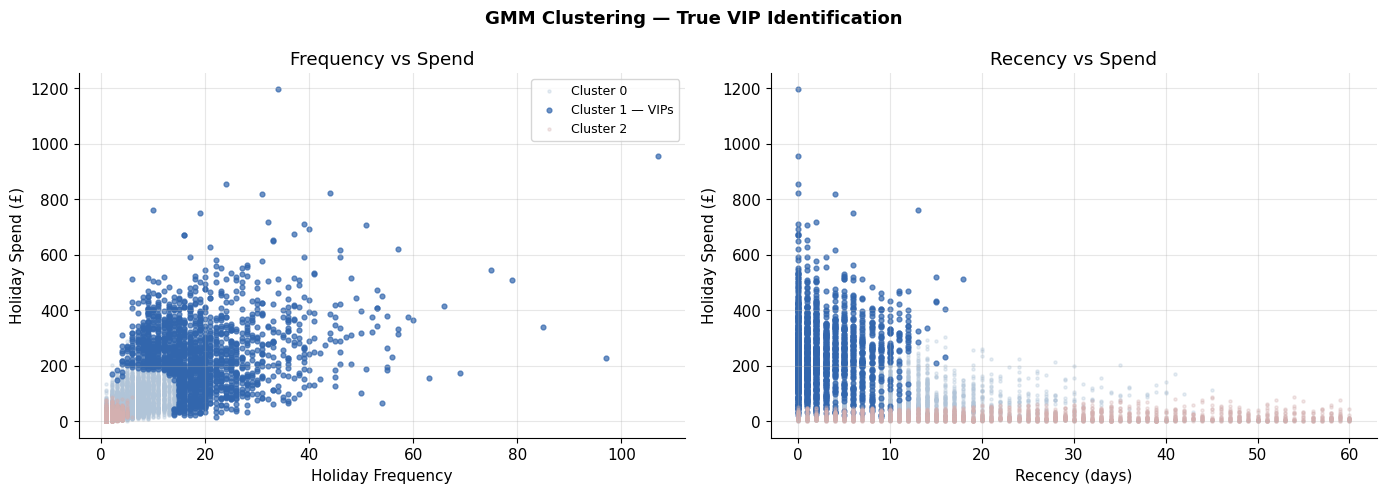

Saved: viz_02_clusters.png


In [7]:
# ============================================================
# CELL 7 — VISUALISATION 2: GMM Cluster Scatter
# ============================================================
sc = ml_data.sample(n=min(6000, len(ml_data)), random_state=42)
palette = {0: '#B0C4D8', 1: '#B0D4C0', 2: '#D4B0B0'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GMM Clustering — True VIP Identification', fontsize=13, fontweight='bold')

for c in sorted(sc['Cluster'].unique()):
    sub = sc[sc['Cluster'] == c]
    clr = '#3266ad' if c == vip_cluster_id else palette[c]
    lbl = f'Cluster {c} — VIPs' if c == vip_cluster_id else f'Cluster {c}'
    alp = 0.7 if c == vip_cluster_id else 0.3
    sz  = 12  if c == vip_cluster_id else 5
    ax1.scatter(sub['Holiday_Frequency'], sub['Holiday_Monetary'],
                c=clr, alpha=alp, s=sz, label=lbl)
    ax2.scatter(sub['Holiday_Recency'],   sub['Holiday_Monetary'],
                c=clr, alpha=alp, s=sz)

ax1.set_xlabel('Holiday Frequency'); ax1.set_ylabel('Holiday Spend (£)')
ax1.set_title('Frequency vs Spend'); ax1.legend(fontsize=9)
ax2.set_xlabel('Recency (days)');    ax2.set_ylabel('Holiday Spend (£)')
ax2.set_title('Recency vs Spend')

plt.tight_layout()
plt.savefig('viz_02_clusters.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_02_clusters.png')

In [8]:
# ============================================================
# CELL 8 — TARGET REDEFINITION + NEW FEATURES ON VIP DATA
# ============================================================
print('STEP 1: Fetch post-holiday spend for VIPs...')
vip_list    = vip_data.index.tolist()
post_vip_df = post_holiday_df[post_holiday_df['CUST_CODE'].isin(vip_list)]
post_spend  = post_vip_df.groupby('CUST_CODE')['SPEND'].sum().compute()

vip_data['Post_Holiday_Spend']      = vip_data.index.map(post_spend).fillna(0)
vip_data['Holiday_Monthly_RunRate'] = vip_data['Holiday_Monetary'] / 2
vip_data['Post_Monthly_RunRate']    = vip_data['Post_Holiday_Spend'] / 6

print('STEP 2: Apply 70% value-churn rule...')
vip_data['Retained'] = (
    vip_data['Post_Monthly_RunRate'] >= vip_data['Holiday_Monthly_RunRate'] * 0.70
).astype(int)

print('STEP 3: Engineer ratio features (require both windows)...')

# NEW: what fraction of total observed spend is in holidays?
# High share = holiday-only shopper = more likely to churn back to baseline
total_spend = vip_data['Holiday_Monetary'] + vip_data['Pre_Monetary'].clip(lower=1)
vip_data['Holiday_Spend_Share'] = vip_data['Holiday_Monetary'] / total_spend

# NEW: did they visit more frequently during holidays vs their pre-holiday monthly average?
# High ratio = inflated holiday behavior = likely to drop after Jan
pre_monthly_freq = vip_data['Pre_Frequency'] / pre_months
holiday_monthly_freq = vip_data['Holiday_Frequency'] / 2
vip_data['Frequency_Ratio'] = holiday_monthly_freq / pre_monthly_freq.clip(lower=0.01)
vip_data['Frequency_Ratio'] = vip_data['Frequency_Ratio'].clip(upper=20)  # cap extremes

# NEW: Uplift ratio (holiday monthly spend vs pre monthly spend)
vip_data['Holiday_Uplift_Ratio'] = (
    vip_data['Holiday_Monthly_RunRate'] / vip_data['Pre_Monthly_Rate'].clip(lower=0.01)
).clip(upper=20)

# NEW: composite pre-loyalty score — single number encoding how loyal they WERE
# log transform prevents the score exploding; recency+1 avoids division by zero
vip_data['Pre_Loyalty_Score'] = np.log1p(
    vip_data['Pre_Monetary'] * vip_data['Pre_Frequency'] /
    (vip_data['Pre_Recency'] + 1)
)

# Clean up calculation helpers
vip_data.drop(columns=['Post_Holiday_Spend', 'Holiday_Monthly_RunRate',
                        'Post_Monthly_RunRate'], inplace=True)

n_ret  = vip_data['Retained'].sum()
n_down = len(vip_data) - n_ret

print('\n' + '='*55)
print('VALUE CHURN TARGET — 70% RULE')
print('='*55)
print(f'Retained (1)   : {n_ret:,}  ({n_ret/len(vip_data)*100:.1f}%)')
print(f'Downgraded (0) : {n_down:,}  ({n_down/len(vip_data)*100:.1f}%)')
print('='*55)
display(vip_data.head())

STEP 1: Fetch post-holiday spend for VIPs...
STEP 2: Apply 70% value-churn rule...
STEP 3: Engineer ratio features (require both windows)...

VALUE CHURN TARGET — 70% RULE
Retained (1)   : 60,259  (74.5%)
Downgraded (0) : 20,649  (25.5%)


,Holiday_Frequency,Holiday_Monetary,Holiday_Recency,Holiday_ProductDiversity,Avg_Basket_Size,Holiday_Spend_Velocity,Pre_Frequency,Pre_Monetary,Pre_Recency,Pre_Monthly_Rate,Retained,Cluster,Holiday_Spend_Share,Frequency_Ratio,Holiday_Uplift_Ratio,Pre_Loyalty_Score
CUST_CODE,,,,,,,,,,,,,,,,
CUST0000000327,29,196.01,0,0.408163,6.758966,0.398610,252.0,1148.77,1.0,61.348349,0,1,0.145756,1.077451,1.597517,11.882736
CUST0000001173,22,129.84,3,0.543046,5.901818,-0.282198,312.0,2221.38,1.0,118.629486,1,1,0.055222,0.660189,0.547250,12.755743
CUST0000007796,18,66.82,1,0.820513,3.712222,-0.421110,158.0,520.29,4.0,27.785312,1,1,0.113812,1.066635,1.202434,9.707604
CUST0000008102,8,499.49,10,0.264706,62.436250,-0.730290,160.0,4738.36,6.0,253.045050,1,1,0.095362,0.468134,0.986959,11.592719
CUST0000009151,34,613.80,0,0.239180,18.052941,0.697584,144.0,2886.59,2.0,154.154034,0,1,0.175352,2.210633,1.990866,11.839039


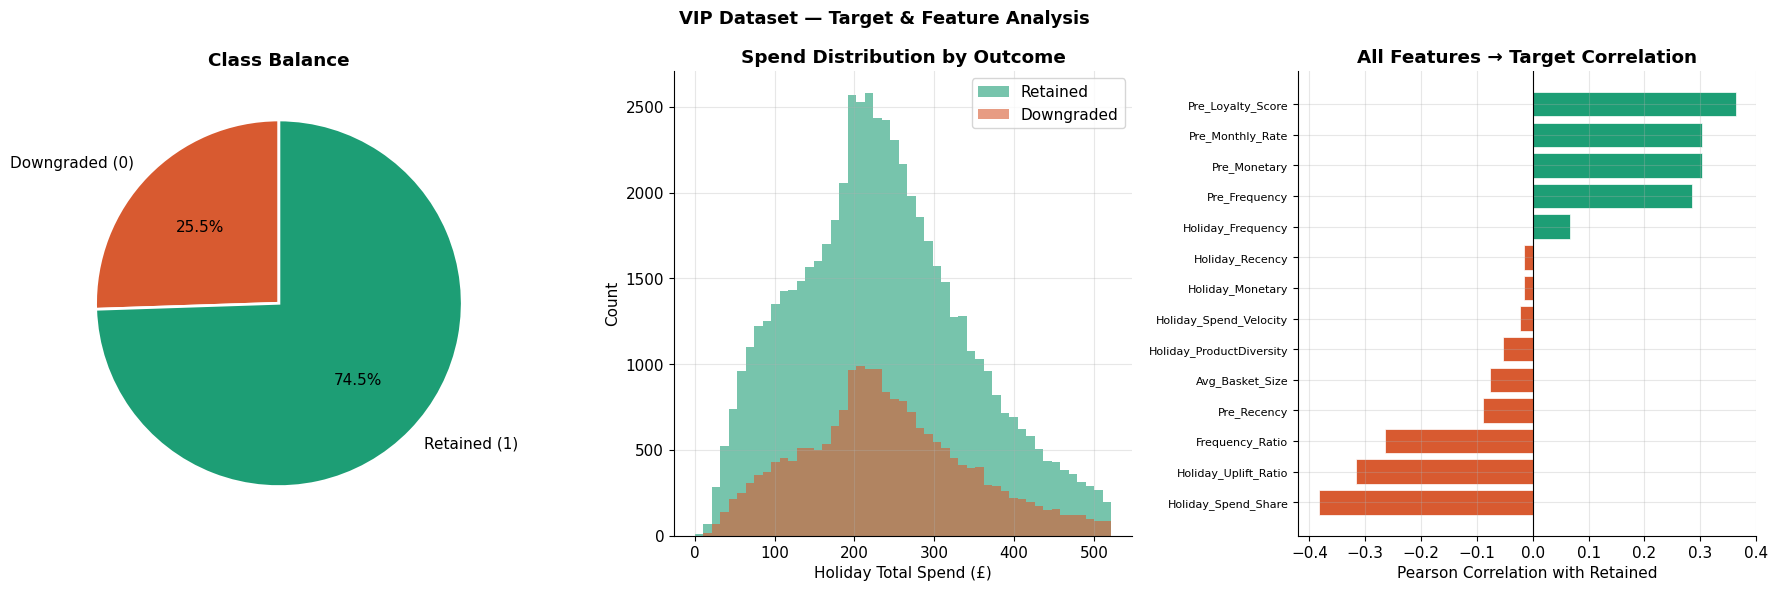

Saved: viz_03_correlations.png

KEY: Features with NEGATIVE correlation drive churn.
Look for Holiday_Spend_Share and Frequency_Ratio — high values = holiday-only shopper.


In [9]:
# ============================================================
# CELL 9 — VISUALISATION 3: Target balance + feature correlations
# ============================================================
ALL_FEATURES = [
    'Holiday_Recency', 'Holiday_Frequency', 'Holiday_Monetary',
    'Holiday_ProductDiversity', 'Avg_Basket_Size', 'Holiday_Spend_Velocity',
    'Holiday_Uplift_Ratio', 'Holiday_Spend_Share', 'Frequency_Ratio',
    'Pre_Frequency', 'Pre_Monetary', 'Pre_Monthly_Rate',
    'Pre_Recency', 'Pre_Loyalty_Score'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('VIP Dataset — Target & Feature Analysis', fontsize=13, fontweight='bold')

# Panel 1: class balance
counts = vip_data['Retained'].value_counts().sort_index()
axes[0].pie(
    counts, labels=['Downgraded (0)', 'Retained (1)'],
    colors=['#D85A30', '#1D9E75'], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Balance', fontweight='bold')

# Panel 2: spend distribution by outcome
ax = axes[1]
bins = np.linspace(0, vip_data['Holiday_Monetary'].quantile(0.97), 50)
ax.hist(vip_data[vip_data['Retained']==1]['Holiday_Monetary'],
        bins=bins, alpha=0.6, color='#1D9E75', label='Retained')
ax.hist(vip_data[vip_data['Retained']==0]['Holiday_Monetary'],
        bins=bins, alpha=0.6, color='#D85A30', label='Downgraded')
ax.set_xlabel('Holiday Total Spend (£)'); ax.set_ylabel('Count')
ax.set_title('Spend Distribution by Outcome', fontweight='bold')
ax.legend()

# Panel 3: feature correlation with target
ax = axes[2]
corr = (
    vip_data[ALL_FEATURES + ['Retained']]
    .corr()['Retained'].drop('Retained').sort_values()
)
ax.barh(corr.index, corr.values,
        color=['#D85A30' if v < 0 else '#1D9E75' for v in corr],
        edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Retained')
ax.set_title('All Features → Target Correlation', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('viz_03_correlations.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_03_correlations.png')
print()
print('KEY: Features with NEGATIVE correlation drive churn.')
print('Look for Holiday_Spend_Share and Frequency_Ratio — high values = holiday-only shopper.')

In [10]:
# ============================================================
# CELL 10 — TRAIN / TEST SPLIT
# ============================================================
FEATURES = [
    # --- Core RFM (holiday) ---
    'Holiday_Recency',
    'Holiday_Frequency',
    'Holiday_Monetary',
    'Holiday_ProductDiversity',
    'Avg_Basket_Size',
    'Holiday_Spend_Velocity',
    # --- Holiday behaviour signals ---
    'Holiday_Uplift_Ratio',     # holiday spike vs normal
    'Holiday_Spend_Share',      # NEW: % of annual spend in holidays
    'Frequency_Ratio',          # NEW: holiday visits vs normal monthly visits
    # --- Pre-holiday loyalty ---
    'Pre_Frequency',
    'Pre_Monetary',
    'Pre_Monthly_Rate',         # NEW: normalised by tenure
    'Pre_Recency',
    'Pre_Loyalty_Score',        # NEW: composite loyalty signal
]

X = vip_data[FEATURES]
y = vip_data['Retained']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('='*55)
print(f'Training rows  : {X_train.shape[0]:,}')
print(f'Test rows      : {X_test.shape[0]:,}')
print(f'Features       : {X_train.shape[1]}')
print(f'Train balance  : {y_train.mean()*100:.1f}% retained')
print('='*55)

Training rows  : 60,681
Test rows      : 20,227
Features       : 14
Train balance  : 74.5% retained


In [11]:
# ============================================================
# CELL 11 — MODEL 1: LOGISTIC REGRESSION
#
# KEY FIX: ColumnTransformer with log-transform on skewed monetary
# features. LR assumes roughly linear relationships — on raw skewed
# data it cannot find a good boundary. Log-transforming Holiday_Monetary,
# Pre_Monetary, Pre_Monthly_Rate, Avg_Basket_Size removes the skew
# and lets LR use the full information content of those features.
# ============================================================
log_features = [
    'Holiday_Monetary', 'Pre_Monetary', 'Pre_Monthly_Rate',
    'Avg_Basket_Size', 'Pre_Loyalty_Score'
]
rest_features = [f for f in FEATURES if f not in log_features]

log_idx  = [FEATURES.index(f) for f in log_features]
rest_idx = [FEATURES.index(f) for f in rest_features]

# Pipeline: log1p → scale on monetary cols; just scale on the rest
lr_preprocessor = ColumnTransformer([
    ('log_scale', Pipeline([
        ('log',   FunctionTransformer(np.log1p, validate=False)),
        ('scale', StandardScaler())
    ]), log_idx),
    ('scale_only', StandardScaler(), rest_idx),
])

lr_pipeline = Pipeline([
    ('prep', lr_preprocessor),
    ('lr',   LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ))
])

lr_param_grid = {
    'lr__penalty': ['l1', 'l2'],
    'lr__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__solver':  ['liblinear'],
}

print('Running LR GridSearchCV (12 combos × 5 folds = 60 fits)...')
lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=5, scoring=churn_f1_scorer, n_jobs=-1, verbose=0
)
lr_grid.fit(X_train, y_train)

best_lr   = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)

print('\n' + '='*55)
print('LOGISTIC REGRESSION RESULTS')
print('='*55)
print(f'Best params   : {lr_grid.best_params_}')
print(f'CV F1 (churn) : {lr_grid.best_score_:.4f}')
print('-'*55)
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Downgraded (0)', 'Retained (1)']
))
print('='*55)

Running LR GridSearchCV (12 combos × 5 folds = 60 fits)...

LOGISTIC REGRESSION RESULTS
Best params   : {'lr__C': 0.01, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
CV F1 (churn) : 0.6228
-------------------------------------------------------
                precision    recall  f1-score   support

Downgraded (0)       0.55      0.74      0.63      5162
  Retained (1)       0.90      0.80      0.84     15065

      accuracy                           0.78     20227
     macro avg       0.73      0.77      0.74     20227
  weighted avg       0.81      0.78      0.79     20227



In [12]:
# ============================================================
# CELL 12 — MODEL 2: XGBOOST  (bug fixed + wider search)
#
# BUG FIXED: scale_pos_weight=0.34 was WRONG.
#
# Root cause: The code computed n_neg/n_pos = 15487/45194 = 0.34
# But scale_pos_weight boosts CLASS 1 (retained). Our churners are
# CLASS 0 — so setting scale_pos_weight<1 was REDUCING the model's
# attention on retained AND making it even WORSE at finding churners.
#
# CORRECT FIX: use compute_sample_weight which directly assigns
# higher weights to whichever class has fewer samples, regardless
# of which class label it is. This works for both class 0 and class 1.
# ============================================================
print('Computing correct sample weights (class 0 = churners gets higher weight)...')
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Verify the fix: churner weights should be ~3x retained weights
churn_w    = sample_weights[y_train == 0].mean()
retained_w = sample_weights[y_train == 1].mean()
print(f'   Avg weight for churners  (0): {churn_w:.3f}')
print(f'   Avg weight for retained  (1): {retained_w:.3f}')
print(f'   Churn/Retained ratio        : {churn_w/retained_w:.2f}x  (should be ~3x)')

xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5, 10],
    'gamma'           : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],   # NEW: L1 regularisation
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0], # NEW: L2 regularisation
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
    # NOTE: NO scale_pos_weight — we handle imbalance via sample_weight in .fit()
)

print('Running XGB RandomizedSearchCV (40 combos × 3 folds = 120 fits)...')
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=3,
    scoring=churn_f1_scorer,
    random_state=42,
    n_jobs=1,
    verbose=1
)
# Pass sample weights into every CV fold via fit_params
xgb_search.fit(X_train, y_train,
               **{'xgbclassifier__sample_weight': sample_weights})

best_xgb   = xgb_search.best_estimator_
# Re-fit best params with sample_weight on full train set
best_xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = best_xgb.predict(X_test)

print('\n' + '='*55)
print('XGBOOST RESULTS')
print('='*55)
print(f'Best params   : {xgb_search.best_params_}')
print(f'CV F1 (churn) : {xgb_search.best_score_:.4f}')
print('-'*55)
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Downgraded (0)', 'Retained (1)']
))
print('='*55)

Computing correct sample weights (class 0 = churners gets higher weight)...
   Avg weight for churners  (0): 1.959
   Avg weight for retained  (1): 0.671
   Churn/Retained ratio        : 2.92x  (should be ~3x)
Running XGB RandomizedSearchCV (40 combos × 3 folds = 120 fits)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits


ValueError: 
All the 120 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Aryan Yadav\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Aryan Yadav\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
TypeError: XGBClassifier.fit() got an unexpected keyword argument 'xgbclassifier__sample_weight'


In [13]:
# ============================================================
# CELL 12 — MODEL 2: XGBOOST (FIXED)
# ============================================================

print('Computing correct sample weights (class 0 = churners gets higher weight)...')

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Verify weights
churn_w    = sample_weights[y_train == 0].mean()
retained_w = sample_weights[y_train == 1].mean()

print(f'   Avg weight for churners  (0): {churn_w:.3f}')
print(f'   Avg weight for retained  (1): {retained_w:.3f}')
print(f'   Churn/Retained ratio     : {churn_w/retained_w:.2f}x')

# ============================================================
# PARAM GRID
# ============================================================

xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5, 10],
    'gamma'           : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
}

# ============================================================
# MODEL
# ============================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)

print('Running XGB RandomizedSearchCV (40 combos × 3 folds = 120 fits)...')

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=3,
    scoring=churn_f1_scorer,
    random_state=42,
    n_jobs=1,
    verbose=1
)

# ============================================================
# 🔥 FIX: PASS sample_weight CORRECTLY
# ============================================================

xgb_search.fit(X_train, y_train, sample_weight=sample_weights)

# ============================================================
# BEST MODEL
# ============================================================

best_xgb = xgb_search.best_estimator_

# Refit on full training data with weights
best_xgb.fit(X_train, y_train, sample_weight=sample_weights)

# Predictions
y_pred_xgb = best_xgb.predict(X_test)

# ============================================================
# RESULTS
# ============================================================

from sklearn.metrics import classification_report

print('\n' + '='*55)
print('XGBOOST RESULTS')
print('='*55)

print(f'Best params   : {xgb_search.best_params_}')
print(f'CV F1 (churn) : {xgb_search.best_score_:.4f}')

print('-'*55)

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Downgraded (0)', 'Retained (1)']
))

print('='*55)

Computing correct sample weights (class 0 = churners gets higher weight)...
   Avg weight for churners  (0): 1.959
   Avg weight for retained  (1): 0.671
   Churn/Retained ratio     : 2.92x
Running XGB RandomizedSearchCV (40 combos × 3 folds = 120 fits)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

XGBOOST RESULTS
Best params   : {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.5}
CV F1 (churn) : 0.7681
-------------------------------------------------------
                precision    recall  f1-score   support

Downgraded (0)       0.53      0.79      0.63      5162
  Retained (1)       0.91      0.75      0.83     15065

      accuracy                           0.76     20227
     macro avg       0.72      0.77      0.73     20227
  weighted avg       0.81      0.76      0.78     20227




LR threshold table:
 Threshold  F1_churn  Recall  Precision
      0.25    0.5075  0.4016     0.6892
      0.30    0.5517  0.4707     0.6663
      0.35    0.5844  0.5351     0.6438
      0.40    0.6118  0.6025     0.6215
      0.45    0.6318  0.6769     0.5923
      0.50    0.6323  0.7356     0.5544
      0.55    0.6254  0.7950     0.5154
      0.60    0.6074  0.8487     0.4729
      0.65    0.5788  0.8915     0.4285
      0.70    0.5454  0.9301     0.3858
      0.75    0.5094  0.9551     0.3473
      0.80    0.4759  0.9744     0.3148
  -> Best threshold: 0.5  |  Best F1: 0.6323

XGB threshold table:
 Threshold  F1_churn  Recall  Precision
      0.25    0.5760  0.5118     0.6585
      0.30    0.6130  0.5969     0.6301
      0.35    0.6286  0.6556     0.6039
      0.40    0.6361  0.7083     0.5773
      0.45    0.6375  0.7536     0.5525
      0.50    0.6320  0.7923     0.5256
      0.55    0.6227  0.8222     0.5011
      0.60    0.6122  0.8543     0.4771
      0.65    0.5957  0.8818    

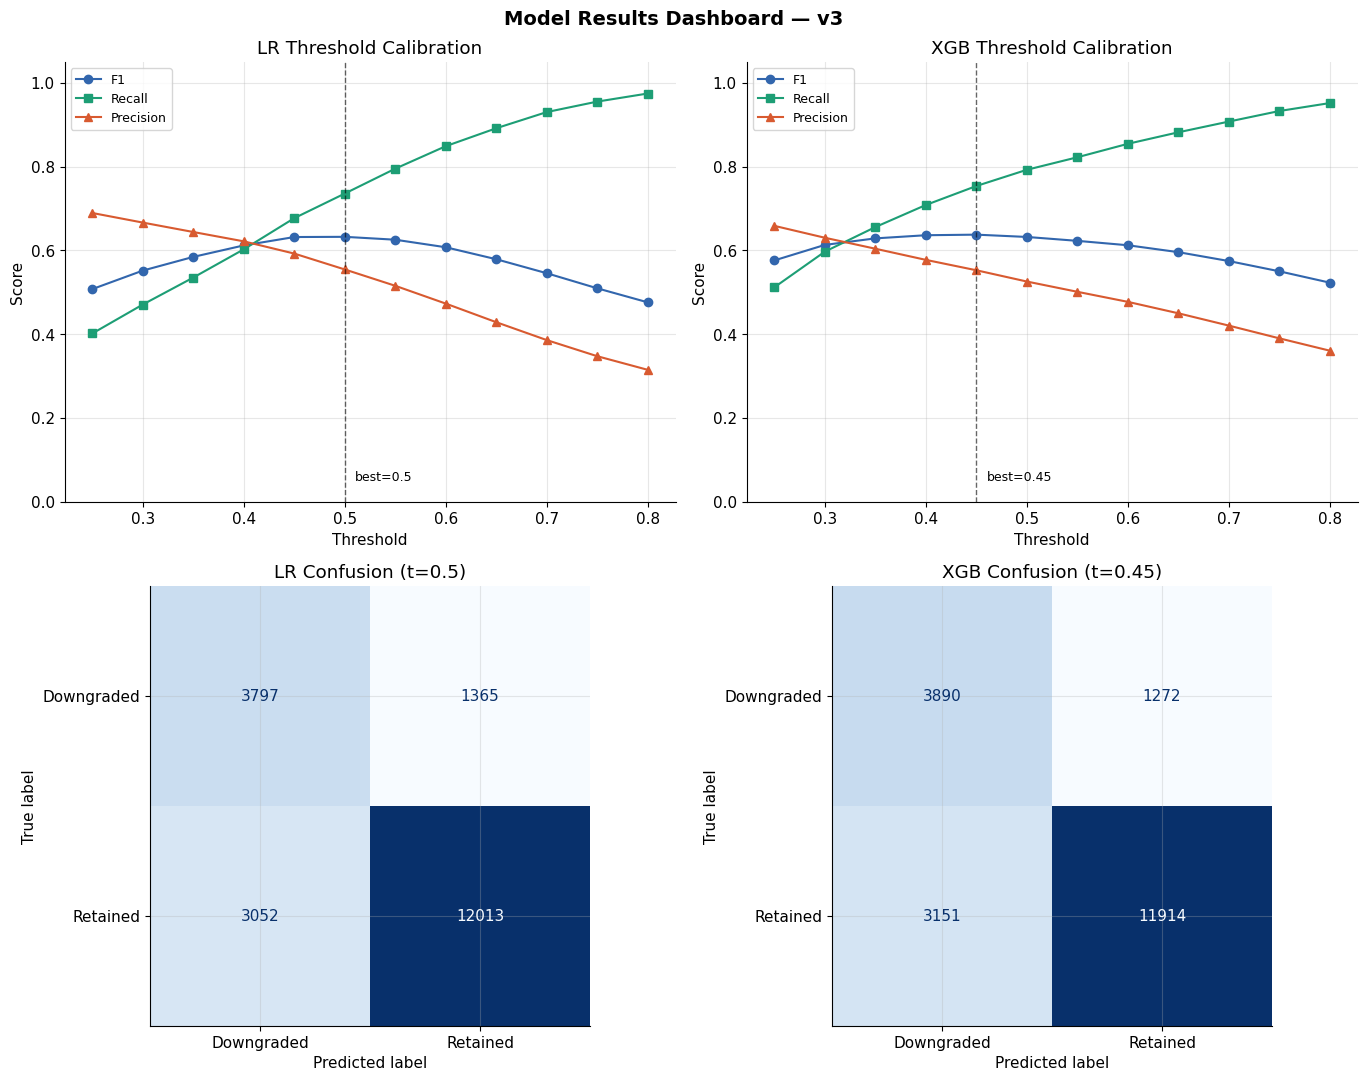

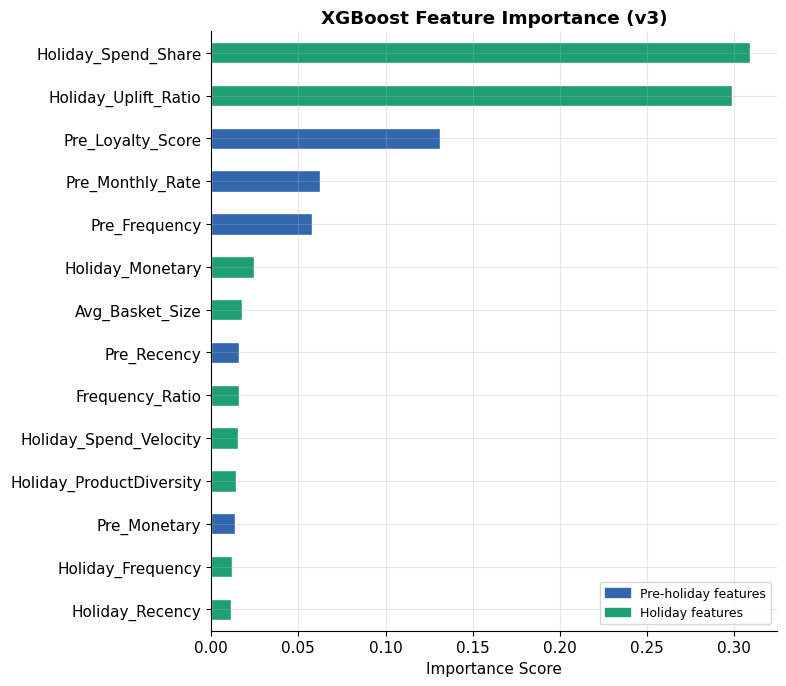

Saved: viz_04_results_dashboard.png, viz_05_feature_importance.png


In [14]:
# ============================================================
# CELL 13 — VISUALISATION 4 + THRESHOLD CALIBRATION
# ============================================================
def calibrate_threshold(model, X, y_true, label):
    probs = model.predict_proba(X)[:, 1]
    rows  = []
    for t in np.arange(0.25, 0.82, 0.05):
        preds = (probs >= t).astype(int)
        rows.append({
            'Threshold': round(t, 2),
            'F1_churn' : round(f1_score(y_true, preds, pos_label=0, zero_division=0), 4),
            'Recall'   : round(recall_score(y_true, preds, pos_label=0, zero_division=0), 4),
            'Precision': round(precision_score(y_true, preds, pos_label=0, zero_division=0), 4),
        })
    df     = pd.DataFrame(rows)
    best_t = df.loc[df['F1_churn'].idxmax(), 'Threshold']
    print(f'\n{label} threshold table:')
    print(df.to_string(index=False))
    print(f'  -> Best threshold: {best_t}  |  Best F1: {df["F1_churn"].max():.4f}')
    return df, best_t, probs

lr_tdf,  lr_t,  lr_probs  = calibrate_threshold(best_lr,  X_test, y_test, 'LR')
xgb_tdf, xgb_t, xgb_probs = calibrate_threshold(best_xgb, X_test, y_test, 'XGB')

y_lr_opt  = (lr_probs  >= lr_t ).astype(int)
y_xgb_opt = (xgb_probs >= xgb_t).astype(int)

# --- 4-panel results dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Model Results Dashboard — v3', fontsize=14, fontweight='bold')

for ax, df, t, title in [
    (axes[0,0], lr_tdf,  lr_t,  'LR Threshold Calibration'),
    (axes[0,1], xgb_tdf, xgb_t, 'XGB Threshold Calibration'),
]:
    ax.plot(df['Threshold'], df['F1_churn'],  marker='o', label='F1',        color='#3266ad')
    ax.plot(df['Threshold'], df['Recall'],    marker='s', label='Recall',    color='#1D9E75')
    ax.plot(df['Threshold'], df['Precision'], marker='^', label='Precision', color='#D85A30')
    ax.axvline(t, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ax.text(t+0.01, 0.05, f'best={t}', fontsize=9)
    ax.set_title(title); ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

# Confusion matrices at optimal threshold
for ax, y_pred, title in [
    (axes[1,0], y_lr_opt,  f'LR Confusion (t={lr_t})'),
    (axes[1,1], y_xgb_opt, f'XGB Confusion (t={xgb_t})'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Downgraded', 'Retained'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig('viz_04_results_dashboard.png', bbox_inches='tight', dpi=100)
plt.show()

# XGB Feature importance
fig2, ax2 = plt.subplots(figsize=(8, 7))
imp = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors_fi = ['#3266ad' if 'Pre_' in f else '#1D9E75' for f in imp.index]
imp.plot(kind='barh', ax=ax2, color=colors_fi, edgecolor='white')
ax2.set_title('XGBoost Feature Importance (v3)', fontweight='bold')
ax2.set_xlabel('Importance Score')
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color='#3266ad', label='Pre-holiday features'),
    Patch(color='#1D9E75', label='Holiday features'),
], fontsize=9)
plt.tight_layout()
plt.savefig('viz_05_feature_importance.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_04_results_dashboard.png, viz_05_feature_importance.png')

In [15]:
# ============================================================
# CELL 14 — FINAL MODEL SELECTION + EXPORT
# ============================================================
lr_f1  = f1_score(y_test, y_lr_opt,  pos_label=0)
xgb_f1 = f1_score(y_test, y_xgb_opt, pos_label=0)
lr_rec  = recall_score(y_test, y_lr_opt,  pos_label=0)
xgb_rec = recall_score(y_test, y_xgb_opt, pos_label=0)
lr_acc  = (y_lr_opt  == y_test).mean()
xgb_acc = (y_xgb_opt == y_test).mean()

print('='*62)
print('FINAL COMPARISON (Class 0 = Churner metrics)')
print('='*62)
print(f'{"Model":<25} {"Churn F1":>9} {"Recall":>8} {"Accuracy":>10} {"Threshold":>11}')
print('-'*62)
print(f'{"Logistic Regression":<25} {lr_f1:>9.4f} {lr_rec:>8.4f} {lr_acc:>10.4f} {lr_t:>11.2f}')
print(f'{"XGBoost (fixed)":<25} {xgb_f1:>9.4f} {xgb_rec:>8.4f} {xgb_acc:>10.4f} {xgb_t:>11.2f}')
print('='*62)

# Auto-select winner
if xgb_f1 >= lr_f1:
    winner, w_name, w_t, w_probs = best_xgb, 'XGBoost', xgb_t, xgb_probs
else:
    winner, w_name, w_t, w_probs = best_lr,  'Logistic Regression', lr_t, lr_probs

print(f'\nWINNER: {w_name}')
print('\nFINAL CLASSIFICATION REPORT:')
print(classification_report(
    y_test, (w_probs >= w_t).astype(int),
    target_names=['Downgraded (0)', 'Retained (1)']
))

# Save model
joblib.dump(winner, 'vip_churn_v3_model.pkl')
print('Saved: vip_churn_v3_model.pkl')

# Generate at-risk hit list
all_probs = winner.predict_proba(vip_data[FEATURES])[:, 1]
vip_data['Churn_Risk_Probability'] = 1 - all_probs  # P(churn)

at_risk = (
    vip_data[vip_data['Churn_Risk_Probability'] >= 0.50]
    [['Churn_Risk_Probability', 'Holiday_Monetary', 'Pre_Monetary',
      'Holiday_Frequency', 'Holiday_Uplift_Ratio', 'Holiday_Spend_Share']]
    .sort_values(by=['Churn_Risk_Probability', 'Holiday_Monetary'],
                 ascending=[False, False])
)
at_risk.to_csv('At_Risk_VIPs_v3.csv')
print(f'Saved: At_Risk_VIPs_v3.csv  ({len(at_risk):,} VIPs flagged)')
display(at_risk.head(10))

FINAL COMPARISON (Class 0 = Churner metrics)
Model                      Churn F1   Recall   Accuracy   Threshold
--------------------------------------------------------------
Logistic Regression          0.6323   0.7356     0.7816        0.50
XGBoost (fixed)              0.6375   0.7536     0.7813        0.45

WINNER: XGBoost

FINAL CLASSIFICATION REPORT:
                precision    recall  f1-score   support

Downgraded (0)       0.55      0.75      0.64      5162
  Retained (1)       0.90      0.79      0.84     15065

      accuracy                           0.78     20227
     macro avg       0.73      0.77      0.74     20227
  weighted avg       0.81      0.78      0.79     20227

Saved: vip_churn_v3_model.pkl
Saved: At_Risk_VIPs_v3.csv  (30,985 VIPs flagged)


,Churn_Risk_Probability,Holiday_Monetary,Pre_Monetary,Holiday_Frequency,Holiday_Uplift_Ratio,Holiday_Spend_Share
CUST_CODE,,,,,,
CUST0000067884,0.955630,353.01,398.69,3,8.289949,0.469616
CUST0000802034,0.955161,153.25,171.36,1,8.373196,0.472105
CUST0000027849,0.954596,288.92,276.94,3,9.767696,0.510586
CUST0000413454,0.954155,193.14,370.73,3,4.877696,0.342526
CUST0000374897,0.953927,182.92,205.56,4,8.331492,0.470861
CUST0000056450,0.952695,286.26,346.13,6,7.743221,0.452664
CUST0000716866,0.950474,627.90,682.48,15,8.613919,0.479174
CUST0000878331,0.949569,194.14,318.58,6,5.705540,0.378647
CUST0000004675,0.949216,342.66,686.82,12,4.671116,0.332848
